In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("diabetes_risk_dataset.csv")
df.head()


,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,Prediabetes
1,2,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,Low Risk
2,3,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,High Risk
3,4,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,High Risk
4,5,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,Prediabetes


In [4]:
X = df[[ "age", "bmi", "blood_pressure", "fasting_glucose_level", "insulin_level"
]]

y = df["diabetes_risk_score"]


In [5]:
df = df.fillna(df.mean(numeric_only=True))
df = df.drop_duplicates()


In [6]:
numeric_cols = ["age", "bmi", "blood_pressure", "fasting_glucose_level", "insulin_level"]

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df_clean = df[~outlier_mask].copy()
df_clean.shape


(5455, 19)

In [7]:
from sklearn.model_selection import train_test_split

X = df_clean[numeric_cols]
y = df_clean["diabetes_risk_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("diabetes_risk_dataset.csv")

# Independent variables
X = df[["age",
        "bmi",
        "blood_pressure",
        "fasting_glucose_level",
        "insulin_level"]]

# Dependent variable
y = df["diabetes_risk_score"]

df.head()


,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,Prediabetes
1,2,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,Low Risk
2,3,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,High Risk
3,4,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,High Risk
4,5,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,Prediabetes


In [14]:
# Numeric columns in the dataset
numeric_cols = ["age", "bmi", "blood_pressure",
                "fasting_glucose_level", "insulin_level"]

# Calculate Q1, Q3, and IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outlier_mask = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

# Count outliers to know the exact numbers
print("Number of outliers:", outlier_mask.sum())

# Remove outliers
df_clean = df[~outlier_mask].copy()

# Show new shape
df_clean.shape


Number of outliers: 545


(5455, 19)

In [16]:
# Independent variables (X) and dependent variable (y)
X = df_clean[["age", "bmi", "blood_pressure",
              "fasting_glucose_level", "insulin_level"]]

y = df_clean["diabetes_risk_score"]

X.head()   


,age,bmi,blood_pressure,fasting_glucose_level,insulin_level
0,77,33.8,154,93,12.1
1,54,19.2,123,94,4.6
2,25,33.7,141,150,10.8
3,23,32.8,140,145,11.6
4,70,33.7,165,90,18.3


In [17]:
from sklearn.model_selection import train_test_split

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape   # SHOW RESULT


((4364, 5), (1091, 5))

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]  


array([[ 0.36768059, -0.01421572, -0.17502389,  0.79189949,  0.19291266],
       [-1.50649038, -1.39739   , -1.19805212, -0.86706381, -1.32477359],
       [-1.45294264, -1.45216918, -2.33475015, -0.98147507, -0.6857478 ],
       [ 1.33153995, -1.43847439,  0.39332513, -0.75265255, -1.16501715],
       [-0.70327425, -1.17827328,  0.16598552, -1.26750323, -0.81127073]])

In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

results = []

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
results.append(["Linear Regression",
                mean_squared_error(y_test, lr_pred),
                r2_score(y_test, lr_pred)])

# Polynomial Regression (Degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_pred = poly_model.predict(X_test_poly)
results.append(["Polynomial Regression (Degree 2)",
                mean_squared_error(y_test, poly_pred),
                r2_score(y_test, poly_pred)])

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
results.append(["Ridge Regression",
                mean_squared_error(y_test, ridge_pred),
                r2_score(y_test, ridge_pred)])

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
results.append(["Lasso Regression",
                mean_squared_error(y_test, lasso_pred),
                r2_score(y_test, lasso_pred)])

# Elastic Net Regression
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)
elastic_pred = elastic.predict(X_test_scaled)
results.append(["Elastic Net",
                mean_squared_error(y_test, elastic_pred),
                r2_score(y_test, elastic_pred)])

# Results Table
results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2"])
results_df


,Model,MSE,R2
0,Linear Regression,120.498811,0.904924
1,Polynomial Regression (Degree 2),108.913317,0.914065
2,Ridge Regression,120.495224,0.904927
3,Lasso Regression,120.579821,0.904860
4,Elastic Net,122.188182,0.903591


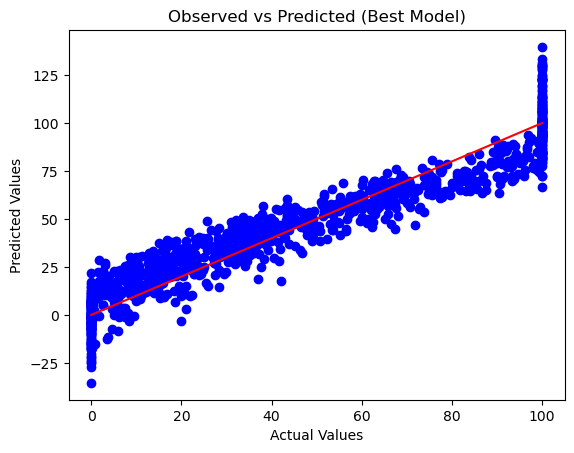

In [29]:
import matplotlib.pyplot as plt

plt.scatter(y_test, lr_pred, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Observed vs Predicted (Best Model)")
plt.show()



In [32]:
print("Intercept:", poly_model.intercept_)
print("Coefficients:", poly_model.coef_)

Intercept: 42.422544133912105
Coefficients: [ 0.00000000e+00  3.64268662e+00  2.19375068e+01  2.05330764e+00
  1.27134224e+01  1.69446550e+00  4.81476487e-01  9.59601849e-01
 -6.26597538e-01 -2.89517811e-01  2.93594581e-01  2.26916374e+00
 -1.19332301e-01 -2.78073287e+00 -3.12628703e-01 -1.17780092e-01
 -2.39212210e-01  1.15037830e+00  1.52124616e-01  2.08675173e-02
 -1.87252023e-01]


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# target
df["risk_category"] = df["diabetes_risk_score"].apply(lambda x: "Low" if x < 50 else "High")

# features
X = df.select_dtypes(include=["number"]).drop("diabetes_risk_score", axis=1).iloc[:, :4]
y = df["risk_category"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results_clf = {}

for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results_clf[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label="High"),
        "Recall": recall_score(y_test, y_pred, pos_label="High"),
        "F1-score": f1_score(y_test, y_pred, pos_label="High")
    }

# table
results_clf_df = pd.DataFrame(results_clf).T
results_clf_df

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.897500,0.899628,0.875226,0.887259
KNN,0.895000,0.896104,0.873418,0.884615
SVM,0.899167,0.913793,0.862568,0.887442
Decision Tree,0.852500,0.846863,0.830018,0.838356
Random Forest,0.888333,0.896030,0.857143,0.876155


In [39]:
df["risk_category"].value_counts()

risk_category
Low     3234
High    2766
Name: count, dtype: int64

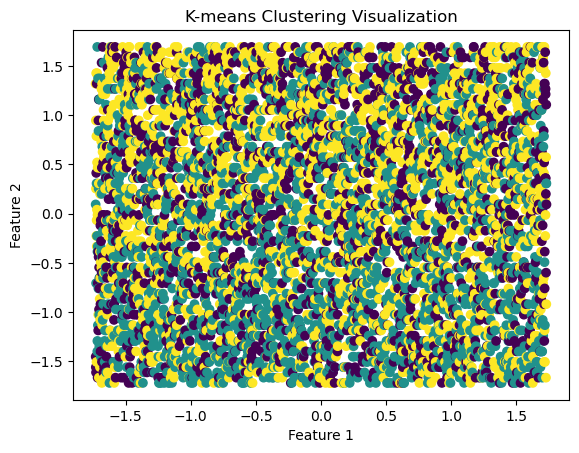

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# اختار الأعمدة الرقمية
X_cluster = df.select_dtypes(include=["number"]).drop("diabetes_risk_score", axis=1)

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# kmeans
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# الرسم
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df["Cluster"], cmap="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-means Clustering Visualization")
plt.show()

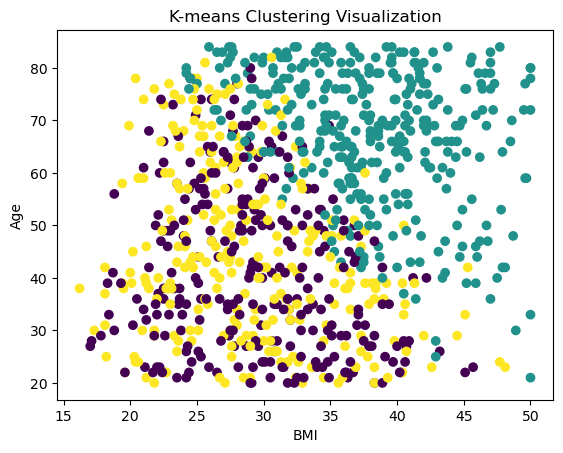

In [52]:
sample_df = df_used.sample(900, random_state=42)

plt.scatter(sample_df["bmi"], sample_df["age"], c=sample_df["Cluster"], cmap="viridis")
plt.xlabel("BMI")
plt.ylabel("Age")
plt.title("K-means Clustering Visualization")
plt.show()